## Section 1 — Centralized Configuration

This is the **single source of truth** for every tunable parameter.
All downstream cells read exclusively from the  namespace.
To switch models or adjust hyperparameters, only edit this cell.

In [1]:
import shutil
import os

SRC = "/kaggle/input/datasets/mohamedmahmoud111/rope-conformer-checkpoints/RoPE_Conformer"
DST = "/kaggle/working/RoPE_Conformer"

# امسح القديم لو موجود (عشان نتأكد 100%)
if os.path.exists(DST):
    shutil.rmtree(DST)

# انسخ من input → working
shutil.copytree(SRC, DST)

print("Checkpoint restored successfully.")

Checkpoint restored successfully.


In [2]:
import os

class CFG:
    # ── Model identity ────────────────────────────────────────────────────────
    MODEL_NAME       = "RoPE_Conformer"       # Switch between models by changing this value

    # ── Training hyperparameters ──────────────────────────────────────────────
    EPOCHS           = 100
    BATCH_SIZE       = 128
    LEARNING_RATE    = 1e-3
    MIN_LR           = 1e-6
    WARMUP_RATIO     = 0.05           # Fraction of total steps used for LR warm-up
    WEIGHT_DECAY     = 1e-4
    LABEL_SMOOTHING  = 0.1
    EARLY_STOP_PAT   = 20             # Early-stopping patience in epochs

    # ── Gradient accumulation ─────────────────────────────────────────────────
    GRAD_ACCUM_STEPS = 1              # Set > 1 to simulate a larger effective batch

    # ── Precision ─────────────────────────────────────────────────────────────
    USE_AMP          = True           # Enable mixed-precision (FP16) training
   
    RESET_CHECKPOINT = False   # اضبطه True لما تغير الـ architecture
                              # ارجعه False بعد أول run ناجح

    # ── Reproducibility ───────────────────────────────────────────────────────
    SEED             = 42

    # ── Data dimensions (must match the Preprocess layer) ────────────────────
    ROWS_PER_FRAME   = 543
    MAX_LEN          = 384
    NUM_CLASSES      = 250
    PAD_VALUE        = -100.0

    # ── Dataset paths ─────────────────────────────────────────────────────────
    DATA_DIR         = "/kaggle/input/competitions/asl-signs"
    TRAIN_CSV        = os.path.join(DATA_DIR, "train.csv")
    LANDMARK_DIR     = os.path.join(DATA_DIR, "train_landmark_files")
    SIGN_MAP         = os.path.join(DATA_DIR, "sign_to_prediction_index_map.json")

    # ── Output root ───────────────────────────────────────────────────────────
    WORKING_DIR      = "/kaggle/working"

    # ── Logging flags ─────────────────────────────────────────────────────────
    USE_LOGGING      = True           # Write structured logs to file
    LOG_LEVEL        = "INFO"        # DEBUG | INFO | WARNING | ERROR

    # ── Comparison summary ────────────────────────────────────────────────────
    COMPARISON_CSV   = os.path.join(WORKING_DIR, "model_comparison_summary.csv")


## Section 2 — Library Imports

All third-party dependencies are imported in one place.
No data pipeline code is modified by this cell.

In [3]:
# Standard library
import sys
import gc
import time
import math
import random
import logging
import datetime
import traceback
import json
from pathlib import Path

# Data and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.autonotebook import tqdm

# Machine learning
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers, metrics, losses, optimizers, mixed_precision
from tensorflow.keras.utils import plot_model


/tmp/ipykernel_22/3676585380.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
2026-04-14 08:17:26.370258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776154646.606830      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776154646.667867      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776154647.189200      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776154647.189243      22 compu

## Section 3 — Logging System

A structured, dual-output logger writes to both a dedicated per-experiment
log file and to stdout. This replaces all bare  statements in
training and evaluation code.

In [4]:
def setup_logger(model_name, log_dir, level="INFO"):
    os.makedirs(log_dir, exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file  = os.path.join(log_dir, f"{model_name}_{timestamp}.log")

    logger = logging.getLogger(model_name)
    logger.setLevel(getattr(logging, level.upper(), logging.INFO))
    logger.handlers.clear()

    fmt = logging.Formatter(
        "[%(asctime)s] [%(name)s] [%(levelname)s]  %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    fh = logging.FileHandler(log_file, encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    logger.propagate = False
    logger.info("Logger initialised — writing to: %s", log_file)
    return logger

logger = logging.getLogger("pipeline")
logging.basicConfig(level=logging.INFO)
logger.info("Temporary root logger active until output directories are ready.")


INFO:pipeline:Temporary root logger active until output directories are ready.


## Section 4 — Reproducibility

Fixed random seeds are applied to Python, NumPy, and TensorFlow.
Deterministic op mode is enabled so that identical runs yield identical results.

In [5]:
os.environ["PYTHONHASHSEED"]      = str(CFG.SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

logger.info("Global seed set to %d. Deterministic ops enabled.", CFG.SEED)


INFO:pipeline:Global seed set to 42. Deterministic ops enabled.


## Section 5 — Device Detection and Mixed Precision

GPUs are detected and memory growth is enabled to avoid OOM errors.
AMP (FP16) is activated when  and a GPU is available,
halving memory usage and increasing throughput with no code changes elsewhere.

In [6]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    logger.info("GPU(s) detected: %s", [g.name for g in gpus])
else:
    logger.warning("No GPU detected — training will run on CPU.")

if CFG.USE_AMP and gpus:
    mixed_precision.set_global_policy("mixed_float16")
    logger.info("Mixed precision policy: mixed_float16")
else:
    mixed_precision.set_global_policy("float32")
    logger.info("Mixed precision disabled — using float32.")

logger.info("TensorFlow  : %s", tf.__version__)
logger.info("Python      : %s", sys.version.split()[0])
logger.info("NumPy       : %s", np.__version__)
logger.info("Pandas      : %s", pd.__version__)
logger.info("Scikit-Learn: %s", sklearn.__version__)


INFO:pipeline:GPU(s) detected: ['/physical_device:GPU:0', '/physical_device:GPU:1']
INFO:pipeline:Mixed precision policy: mixed_float16
INFO:pipeline:TensorFlow  : 2.19.0
INFO:pipeline:Python      : 3.12.12
INFO:pipeline:NumPy       : 2.0.2
INFO:pipeline:Pandas      : 2.3.3
INFO:pipeline:Scikit-Learn: 1.6.1


## Section 6 — Output Directory Structure

A standardised directory tree is created for every model:



In [7]:
def build_output_dirs(working_dir, model_name):
    base = os.path.join(working_dir, model_name)
    dirs = {
        "base":        base,
        "checkpoints": os.path.join(base, "checkpoints"),
        "logs":        os.path.join(base, "logs"),
        "metrics":     os.path.join(base, "metrics"),
        "predictions": os.path.join(base, "predictions"),
        "plots":       os.path.join(base, "plots"),
    }
    for path in dirs.values():
        os.makedirs(path, exist_ok=True)
    return dirs

DIRS = build_output_dirs(CFG.WORKING_DIR, CFG.MODEL_NAME)

logger = setup_logger(CFG.MODEL_NAME, DIRS["logs"], CFG.LOG_LEVEL)
logger.info("Output directories ready: %s", DIRS["base"])


[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Logger initialised — writing to: /kaggle/working/RoPE_Conformer/logs/RoPE_Conformer_20260414_081751.log
[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Output directories ready: /kaggle/working/RoPE_Conformer


## Section 7 — Data Paths

Input paths are derived from  and verified.
**This cell is part of the protected data pipeline and must not be modified.**

In [8]:
DATA_DIR     = Path(CFG.DATA_DIR)
TRAIN_CSV    = Path(CFG.TRAIN_CSV)
LANDMARK_DIR = Path(CFG.LANDMARK_DIR)
SIGN_MAP     = Path(CFG.SIGN_MAP)

logger.info("DATA_DIR     : %s  exists=%s", DATA_DIR,     DATA_DIR.exists())
logger.info("TRAIN_CSV    : %s  exists=%s", TRAIN_CSV,    TRAIN_CSV.exists())
logger.info("LANDMARK_DIR : %s  exists=%s", LANDMARK_DIR, LANDMARK_DIR.exists())

parquet_folders = list(LANDMARK_DIR.glob("*")) if LANDMARK_DIR.exists() else []
logger.info("Parquet participant folders found: %d", len(parquet_folders))


[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  DATA_DIR     : /kaggle/input/competitions/asl-signs  exists=True
[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  TRAIN_CSV    : /kaggle/input/competitions/asl-signs/train.csv  exists=True
[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  LANDMARK_DIR : /kaggle/input/competitions/asl-signs/train_landmark_files  exists=True
[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Parquet participant folders found: 21


## Section 8 — Raw Data Loading

The training manifest CSV is loaded and its shape is logged.
**This cell is part of the protected data pipeline and must not be modified.**

In [9]:
train_df = pd.read_csv(TRAIN_CSV)
display(train_df.head())
display(train_df.info())

logger.info("train.csv: %d rows | %d unique signs | %d participants",
            len(train_df), train_df["sign"].nunique(), train_df["participant_id"].nunique())


,path,participant_id,sequence_id,sign
0,train_landmark_files/26734/1000035562.parquet,26734,1000035562,blow
1,train_landmark_files/28656/1000106739.parquet,28656,1000106739,wait
2,train_landmark_files/16069/100015657.parquet,16069,100015657,cloud
3,train_landmark_files/25571/1000210073.parquet,25571,1000210073,bird
4,train_landmark_files/62590/1000240708.parquet,62590,1000240708,owie


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.9+ MB


None

[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  train.csv: 94477 rows | 250 unique signs | 21 participants


## Section 9 — Spatial-Temporal Feature Engineering

This block defines the core preprocessing pipeline:

1. **Landmark index sets** — 543 raw MediaPipe nodes are reduced to the most
   informative subset (lips, eyes, nose, hands), reducing noise and compute.
2. **NaN-safe statistics** —  /  handle frames with
   missing detections without propagating  through the network.
3. ** Keras layer** — a differentiable, graph-compatible layer that
   normalises coordinates, computes velocity (first derivative) and acceleration
   (second derivative) across frames, and concatenates them into a single feature
   vector of shape .

**This cell is part of the protected data pipeline and must not be modified.**

In [10]:
# ── Data constants ────────────────────────────────────────────────────────────
ROWS_PER_FRAME = CFG.ROWS_PER_FRAME
MAX_LEN        = CFG.MAX_LEN
CROP_LEN       = MAX_LEN
NUM_CLASSES    = CFG.NUM_CLASSES
PAD            = CFG.PAD_VALUE

# ── Landmark index definitions ────────────────────────────────────────────────
NOSE  = [1, 2, 98, 327]
LNOSE = [98]
RNOSE = [327]

LIP = [
    0, 61, 185, 40, 39, 37, 267, 269, 270, 409,
    291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
    95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
]
LLIP = [84, 181, 91, 146, 61, 185, 40, 39, 37, 87, 178, 88, 95, 78, 191, 80, 81, 82]
RLIP = [314, 405, 321, 375, 291, 409, 270, 269, 267, 317, 402, 318, 324, 308, 415, 310, 311, 312]

POSE  = [500, 502, 504, 501, 503, 505, 512, 513]
LPOSE = [513, 505, 503, 501]
RPOSE = [512, 504, 502, 500]

REYE = [33, 7, 163, 144, 145, 153, 154, 155, 133, 246, 161, 160, 159, 158, 157, 173]
LEYE = [263, 249, 390, 373, 374, 380, 381, 382, 362, 466, 388, 387, 386, 385, 384, 398]

LHAND = np.arange(468, 489).tolist()
RHAND = np.arange(522, 543).tolist()

POINT_LANDMARKS = LIP + LHAND + RHAND + NOSE + REYE + LEYE

NUM_NODES = len(POINT_LANDMARKS)
CHANNELS  = 6 * NUM_NODES   # (X, Y) x (position, velocity, acceleration)

logger.info("Selected landmark nodes: %d  |  Feature channels: %d", NUM_NODES, CHANNELS)


# ── NaN-safe statistics ───────────────────────────────────────────────────────
def tf_nan_mean(x, axis=0, keepdims=False):
    sum_val   = tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), x),    axis=axis, keepdims=keepdims)
    count_val = tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), tf.ones_like(x)), axis=axis, keepdims=keepdims)
    return sum_val / count_val

def tf_nan_std(x, center=None, axis=0, keepdims=False):
    if center is None:
        center = tf_nan_mean(x, axis=axis, keepdims=True)
    d = x - center
    return tf.math.sqrt(tf_nan_mean(d * d, axis=axis, keepdims=keepdims))


# ── Preprocess Keras layer ────────────────────────────────────────────────────
class Preprocess(tf.keras.layers.Layer):
    def __init__(self, max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS, **kwargs):
        super().__init__(**kwargs)
        self.max_len         = max_len
        self.point_landmarks = point_landmarks

    def call(self, inputs):
        if inputs.shape.rank == 3:
            x = inputs[None, ...]
        else:
            x = inputs

        mean = tf_nan_mean(tf.gather(x, [17], axis=2), axis=[1, 2], keepdims=True)
        mean = tf.where(tf.math.is_nan(mean), tf.constant(0.5, x.dtype), mean)

        x   = tf.gather(x, self.point_landmarks, axis=2)
        std = tf_nan_std(x, center=mean, axis=[1, 2], keepdims=True)
        x   = (x - mean) / std

        if self.max_len is not None:
            x = x[:, :self.max_len]

        length = tf.shape(x)[1]
        x = x[..., :2]

        dx = tf.cond(
            tf.shape(x)[1] > 1,
            lambda: tf.pad(x[:, 1:] - x[:, :-1], [[0,0],[0,1],[0,0],[0,0]]),
            lambda: tf.zeros_like(x),
        )
        dx2 = tf.cond(
            tf.shape(x)[1] > 2,
            lambda: tf.pad(x[:, 2:] - x[:, :-2], [[0,0],[0,2],[0,0],[0,0]]),
            lambda: tf.zeros_like(x),
        )

        x = tf.concat([
            tf.reshape(x,   (-1, length, 2 * len(self.point_landmarks))),
            tf.reshape(dx,  (-1, length, 2 * len(self.point_landmarks))),
            tf.reshape(dx2, (-1, length, 2 * len(self.point_landmarks))),
        ], axis=-1)

        x = tf.where(tf.math.is_nan(x), tf.constant(0., x.dtype), x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len, "point_landmarks": self.point_landmarks})
        return config


preprocess_layer = Preprocess(max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS)
logger.info("Preprocess layer instantiated.")


[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Selected landmark nodes: 118  |  Feature channels: 708
[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Preprocess layer instantiated.


## Section 10 — Data Augmentation and Parquet Pipeline

Five spatiotemporal augmentations improve generalisation:

| Augmentation | Effect |
|---|---|
|  | Mirrors hands and face (left ↔ right signer) |
|  | Randomly alters signing speed |
|  | Rotation, scale, and shear transforms |
|  | Blanks a random contiguous time window |
|  | Blanks a random spatial region per frame |

 wraps a Python generator in 
and returns a prefetch-optimised pipeline.

**This cell is part of the protected data pipeline and must not be modified.**

In [11]:
# ── Label encoding ────────────────────────────────────────────────────────────
if "label" not in train_df.columns:
    sign_list     = sorted(train_df["sign"].unique())
    sign_to_label = {sign: label for label, sign in enumerate(sign_list)}
    label_to_sign = {label: sign for sign, label in sign_to_label.items()}
    train_df["label"] = train_df["sign"].map(sign_to_label)
    logger.info("Encoded %d unique sign classes.", len(sign_list))


# ── Parquet reader ─────────────────────────────────────────────────────────────
def load_parquet_video(file_path):
    try:
        df     = pd.read_parquet(file_path, columns=["x", "y", "z"], engine="pyarrow")
        coords = df.values.astype(np.float32)
        frames = len(coords) // ROWS_PER_FRAME
        return coords.reshape(frames, ROWS_PER_FRAME, 3)
    except Exception:
        return np.zeros((0, ROWS_PER_FRAME, 3), dtype=np.float32)


# ── Augmentation helpers ───────────────────────────────────────────────────────
def filter_nans_tf(x, ref_point=POINT_LANDMARKS):
    mask = tf.math.logical_not(
        tf.reduce_all(tf.math.is_nan(tf.gather(x, ref_point, axis=1)), axis=[-2, -1])
    )
    return tf.boolean_mask(x, mask, axis=0)


def flip_lr(x):
    x_coord, y_coord, z_coord = tf.unstack(x, axis=-1)
    x_coord = 1 - x_coord
    new_x   = tf.stack([x_coord, y_coord, z_coord], -1)
    new_x   = tf.transpose(new_x, [1, 0, 2])
    for left, right in [(LHAND, RHAND), (LLIP, RLIP), (LPOSE, RPOSE), (LEYE, REYE), (LNOSE, RNOSE)]:
        lv    = tf.gather(new_x, left,  axis=0)
        rv    = tf.gather(new_x, right, axis=0)
        new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(left) [..., None], rv)
        new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(right)[..., None], lv)
    return tf.transpose(new_x, [1, 0, 2])


def interp1d_(x, target_len, method="random"):
    target_len = tf.maximum(1, target_len)
    width      = tf.shape(x)[1]
    size       = [target_len, width]
    if method == "random":
        rand_val = tf.random.uniform(())
        if rand_val < 0.33:
            x = tf.image.resize(x, size, "bilinear")
        elif rand_val < 0.66:
            x = tf.image.resize(x, size, "bicubic")
        else:
            x = tf.image.resize(x, size, "nearest")
    else:
        x = tf.image.resize(x, size, method)
    return x


def resample(x, rate=(0.8, 1.2)):
    rate     = tf.random.uniform((), rate[0], rate[1])
    length   = tf.shape(x)[0]
    new_size = tf.cast(rate * tf.cast(length, tf.float32), tf.int32)
    return interp1d_(x, new_size)


def spatial_random_affine(xyz, scale=(0.8, 1.2), shear=(-0.15, 0.15), shift=(-0.1, 0.1), degree=(-30, 30)):
    center = tf.constant([0.5, 0.5])
    if scale is not None:
        xyz = tf.random.uniform((), *scale) * xyz
    if shear is not None:
        xy, z   = xyz[..., :2], xyz[..., 2:]
        shear_x = shear_y = tf.random.uniform((), *shear)
        if tf.random.uniform(()) < 0.5:
            shear_x = 0.
        else:
            shear_y = 0.
        shear_mat = tf.identity([[1., shear_x], [shear_y, 1.]])
        xy        = xy @ shear_mat
        center    = center + [shear_y, shear_x]
        xyz       = tf.concat([xy, z], axis=-1)
    if degree is not None:
        xy, z   = xyz[..., :2], xyz[..., 2:]
        xy     -= center
        radian  = tf.random.uniform((), *degree) / 180 * np.pi
        c, s    = tf.math.cos(radian), tf.math.sin(radian)
        rot     = tf.identity([[c, s], [-s, c]])
        xy      = xy @ rot + center
        xyz     = tf.concat([xy, z], axis=-1)
    if shift is not None:
        xyz = xyz + tf.random.uniform((), *shift)
    return xyz


def temporal_crop(x, length=MAX_LEN):
    l      = tf.shape(x)[0]
    offset = tf.random.uniform((), 0, tf.clip_by_value(l - length, 1, length), dtype=tf.int32)
    return x[offset: offset + length]


def temporal_mask(x, size=(0.2, 0.4), mask_value=float("nan")):
    l           = tf.shape(x)[0]
    mask_size   = tf.cast(tf.cast(l, tf.float32) * tf.random.uniform((), *size), tf.int32)
    mask_offset = tf.random.uniform((), 0, tf.clip_by_value(l - mask_size, 1, l), dtype=tf.int32)
    indices     = tf.range(mask_offset, mask_offset + mask_size)[..., None]
    updates     = tf.fill([mask_size, ROWS_PER_FRAME, 3], mask_value)
    return tf.tensor_scatter_nd_update(x, indices, updates)


def spatial_mask(x, size=(0.2, 0.4), mask_value=float("nan")):
    mask_offset_y = tf.random.uniform(())
    mask_offset_x = tf.random.uniform(())
    mask_size     = tf.random.uniform((), *size)
    mask_x        = (mask_offset_x < x[..., 0]) & (x[..., 0] < mask_offset_x + mask_size)
    mask_y        = (mask_offset_y < x[..., 1]) & (x[..., 1] < mask_offset_y + mask_size)
    return tf.where((mask_x & mask_y)[..., None], mask_value, x)


def augment_fn(x, max_len=None):
    if tf.random.uniform(()) < 0.80: x = resample(x, (0.5, 1.5))
    if tf.random.uniform(()) < 0.50: x = flip_lr(x)
    if max_len is not None:           x = temporal_crop(x, max_len)
    if tf.random.uniform(()) < 0.75: x = spatial_random_affine(x)
    if tf.random.uniform(()) < 0.50: x = temporal_mask(x)
    if tf.random.uniform(()) < 0.50: x = spatial_mask(x)
    return x


def process_data(coord, label, augment=False, max_len=MAX_LEN):
    coord     = filter_nans_tf(coord)
    if augment:
        coord = augment_fn(coord, max_len=max_len)
    coord     = tf.ensure_shape(coord, (None, ROWS_PER_FRAME, 3))
    processed = preprocess_layer(coord)
    processed = tf.squeeze(processed, axis=0)
    processed = tf.cast(processed, tf.float32)
    return processed, tf.one_hot(label, NUM_CLASSES)


def get_parquet_dataset(df, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
                        max_len=MAX_LEN, augment=False, shuffle=False):
    def generator():
        sample_df = df.sample(frac=1).reset_index(drop=True) if shuffle else df
        for _, row in sample_df.iterrows():
            file_path = os.path.normpath(
                os.path.join(data_dir, str(row["path"]).replace("\\", "/"))
            )
            coords = load_parquet_video(file_path)
            if coords.shape[0] > 0:
                yield coords, int(row["label"])

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, ROWS_PER_FRAME, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(),                        dtype=tf.int32),
        ),
    )
    ds = ds.map(
        lambda x, y: process_data(x, y, augment=augment, max_len=max_len),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.padded_batch(
        batch_size,
        padding_values=(tf.cast(PAD, tf.float32), tf.cast(0.0, tf.float32)),
        padded_shapes=([max_len, CHANNELS], [NUM_CLASSES]),
        drop_remainder=True,
    )
    ds = ds.repeat()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


[2026-04-14 08:17:51] [RoPE_Conformer] [INFO]  Encoded 250 unique sign classes.


## Section 11 — Pipeline Sanity Check

A small batch is run through the pipeline to verify tensor shapes and dtypes
before any expensive computation begins.

In [12]:
logger.info("Running pipeline sanity check on 10 samples...")
_test_ds = get_parquet_dataset(train_df.head(10), batch_size=2, augment=True)
for _bx, _by in _test_ds.take(1):
    logger.info("Sanity check X: %s  Y: %s  dtype: %s", _bx.shape, _by.shape, _bx.dtype)
del _test_ds
gc.collect()


[2026-04-14 08:17:52] [RoPE_Conformer] [INFO]  Running pipeline sanity check on 10 samples...


I0000 00:00:1776154672.444578      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776154672.450871      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-04-14 08:17:53.886348: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be 

[2026-04-14 08:17:54] [RoPE_Conformer] [INFO]  Sanity check X: (2, 384, 708)  Y: (2, 250)  dtype: <dtype: 'float32'>


5264

## Section 12 — Batch Tensor Inspection

One batch is extracted and its statistical properties are logged to confirm
that normalisation is centred near zero and one-hot encoding is correct.

In [13]:
_inspect_ds = get_parquet_dataset(train_df.head(10), batch_size=2, augment=False)
for _bx, _by in _inspect_ds.take(1):
    _x = _bx.numpy()
    _y = _by.numpy()
    logger.info("Feature tensor — shape: %s  min: %.4f  max: %.4f  mean: %.4f",
                _x.shape, _x.min(), _x.max(), _x.mean())
    logger.info("Label tensor   — shape: %s  active class: %d  (%s)",
                _y.shape, _y[0].argmax(), label_to_sign.get(int(_y[0].argmax()), "unknown"))
del _inspect_ds
gc.collect()


[2026-04-14 08:17:54] [RoPE_Conformer] [INFO]  Feature tensor — shape: (2, 384, 708)  min: -100.0000  max: 4.2930  mean: -95.5772
[2026-04-14 08:17:54] [RoPE_Conformer] [INFO]  Label tensor   — shape: (2, 250)  active class: 25  (blow)


1712

## Section 13 — Stratified Train / Validation / Test Split

The dataset is split 80% / 10% / 10% with stratification on the class label
to ensure consistent class frequencies across all three sets.  Splits are
written to disk so that every model in the comparison trains and evaluates on
exactly the same partitions.

**This cell is part of the protected data pipeline and must not be modified.**

In [14]:
logger.info("Performing stratified 80/10/10 split  seed=%d.", CFG.SEED)

_data_dir = os.path.join(DIRS["base"], "data")
os.makedirs(_data_dir, exist_ok=True)

train_df_split, temp_df = train_test_split(
    train_df, test_size=0.20, random_state=CFG.SEED, stratify=train_df["label"]
)
val_df_split, test_df_split = train_test_split(
    temp_df, test_size=0.50, random_state=CFG.SEED, stratify=temp_df["label"]
)

train_df_split.to_csv(os.path.join(_data_dir, "train_split.csv"), index=False)
val_df_split  .to_csv(os.path.join(_data_dir, "val_split.csv"),   index=False)
test_df_split .to_csv(os.path.join(_data_dir, "test_split.csv"),  index=False)

logger.info("Training   : %d samples  (%.1f%%)", len(train_df_split), 100*len(train_df_split)/len(train_df))
logger.info("Validation : %d samples  (%.1f%%)", len(val_df_split),   100*len(val_df_split)/len(train_df))
logger.info("Test       : %d samples  (%.1f%%)", len(test_df_split),  100*len(test_df_split)/len(train_df))


[2026-04-14 08:17:55] [RoPE_Conformer] [INFO]  Performing stratified 80/10/10 split  seed=42.
[2026-04-14 08:17:55] [RoPE_Conformer] [INFO]  Training   : 75581 samples  (80.0%)
[2026-04-14 08:17:55] [RoPE_Conformer] [INFO]  Validation : 9448 samples  (10.0%)
[2026-04-14 08:17:55] [RoPE_Conformer] [INFO]  Test       : 9448 samples  (10.0%)


## Section 14 — Dataset Construction

Three  pipelines are instantiated from the splits.
Augmentation and shuffling are applied **only** to the training pipeline.
Steps-per-epoch are derived from split sizes and batch size.

In [15]:
train_dataset = get_parquet_dataset(
    train_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=True, shuffle=True,
)
val_dataset = get_parquet_dataset(
    val_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=False, shuffle=False,
)
test_dataset = get_parquet_dataset(
    test_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=False, shuffle=False,
)

steps_per_epoch  = len(train_df_split) // CFG.BATCH_SIZE
validation_steps = len(val_df_split)   // CFG.BATCH_SIZE
test_steps       = len(test_df_split)  // CFG.BATCH_SIZE

logger.info("Steps/epoch: %d  |  Val steps: %d  |  Test steps: %d",
            steps_per_epoch, validation_steps, test_steps)


[2026-04-14 08:17:56] [RoPE_Conformer] [INFO]  Steps/epoch: 590  |  Val steps: 73  |  Test steps: 73


## Section 15 — Pre-Training Dataset Report

A statistical summary of the split is saved to disk and visualised as
a pie chart (allocation) and bar chart (per-class sample count).

[2026-04-14 08:17:56] [RoPE_Conformer] [INFO]  =========================================================
       DATASET REPORT — RoPE_Conformer
Total sequences         : 94477
Unique classes          : 250
Selected landmark nodes : 118
Feature channels        : 708
Max sequence length     : 384 frames
Input tensor shape      : (Batch, 384, 708)
---------------------------------------------------------
Training   : 75581 samples
Validation : 9448 samples
Test       : 9448 samples
---------------------------------------------------------
[Train] max=332  min=239  mean=302.3
[Val]   max=42  min=30  mean=37.8
[Test]  max=41  min=30  mean=37.8



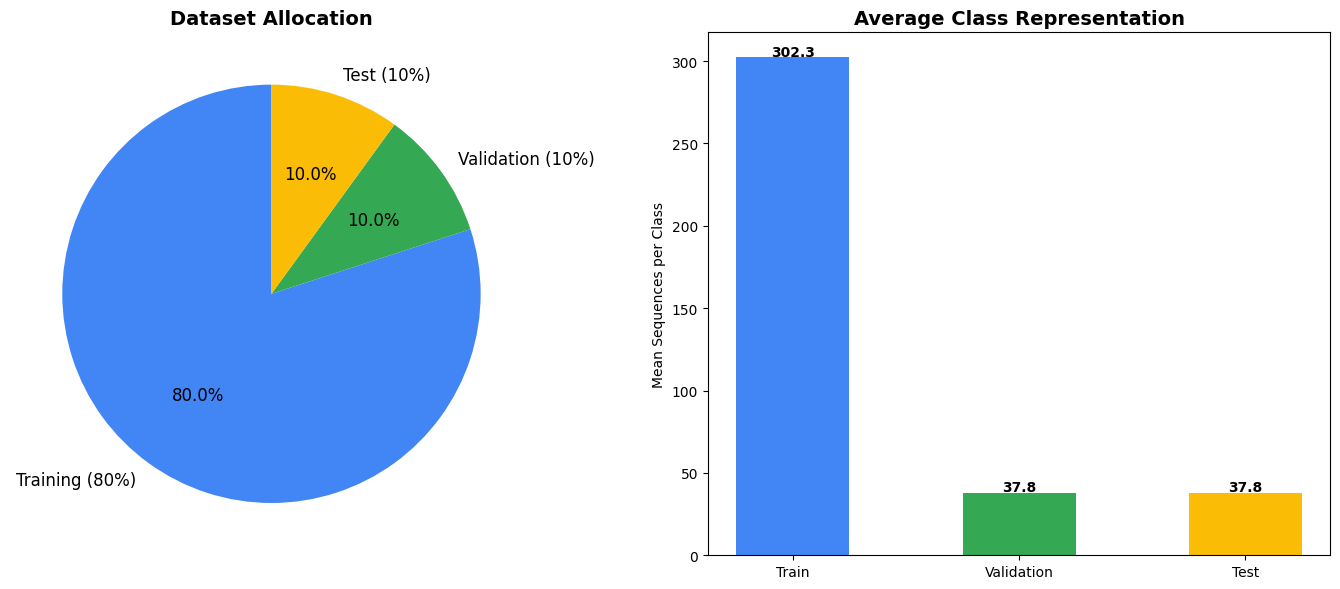

[2026-04-14 08:17:56] [RoPE_Conformer] [INFO]  Pre-training report saved.


In [16]:
_tc = train_df_split["label"].value_counts()
_vc = val_df_split  ["label"].value_counts()
_xc = test_df_split ["label"].value_counts()

_report = (
    f"=========================================================\n"
    f"       DATASET REPORT — {CFG.MODEL_NAME}\n"
    f"=========================================================\n"
    f"Total sequences         : {len(train_df)}\n"
    f"Unique classes          : {NUM_CLASSES}\n"
    f"Selected landmark nodes : {NUM_NODES}\n"
    f"Feature channels        : {CHANNELS}\n"
    f"Max sequence length     : {MAX_LEN} frames\n"
    f"Input tensor shape      : (Batch, {MAX_LEN}, {CHANNELS})\n"
    f"---------------------------------------------------------\n"
    f"Training   : {len(train_df_split)} samples\n"
    f"Validation : {len(val_df_split)} samples\n"
    f"Test       : {len(test_df_split)} samples\n"
    f"---------------------------------------------------------\n"
    f"[Train] max={_tc.max()}  min={_tc.min()}  mean={_tc.mean():.1f}\n"
    f"[Val]   max={_vc.max()}  min={_vc.min()}  mean={_vc.mean():.1f}\n"
    f"[Test]  max={_xc.max()}  min={_xc.min()}  mean={_xc.mean():.1f}\n"
    f"=========================================================\n"
)
logger.info(_report)

with open(os.path.join(DIRS["metrics"], "dataset_report.txt"), "w") as _f:
    _f.write(_report)

_fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(14, 6))
_ax1.pie(
    [len(train_df_split), len(val_df_split), len(test_df_split)],
    labels=["Training (80%)", "Validation (10%)", "Test (10%)"],
    colors=["#4285F4", "#34A853", "#FBBC05"],
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
)
_ax1.set_title("Dataset Allocation", fontsize=14, fontweight="bold")

_means = [_tc.mean(), _vc.mean(), _xc.mean()]
_ax2.bar(["Train", "Validation", "Test"], _means,
         color=["#4285F4", "#34A853", "#FBBC05"], width=0.5)
_ax2.set_ylabel("Mean Sequences per Class")
_ax2.set_title("Average Class Representation", fontsize=14, fontweight="bold")
for _i, _v in enumerate(_means):
    _ax2.text(_i, _v + 1, f"{_v:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "data_split_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
logger.info("Pre-training report saved.")



## **Section 16 — Model Architecture

In [17]:
# ---------------------------------------------------------------------------
# Utility layers (mask-safe replacements for Lambda)
# ---------------------------------------------------------------------------

class MaskableConv1D(layers.Conv1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True


class Squeeze(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.squeeze(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class ExpandDims(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.expand_dims(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class ReduceSum(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.reduce_sum(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class MaskableGlobalMaxPool1D(layers.GlobalMaxPooling1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True


class AttentionMaskFromInput(layers.Layer):
    def __init__(self, pad_value=-100.0, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.supports_masking = True
        self.pad_value = pad_value
    def call(self, x):
        bool_mask = tf.reduce_any(tf.not_equal(x, self.pad_value), axis=-1)
        return tf.expand_dims(bool_mask, axis=1)
    def get_config(self):
        return {**super().get_config(), "pad_value": self.pad_value}


# ---------------------------------------------------------------------------
# Rotary Position Embedding (RoPE)
# Su et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding", 2021.
# ---------------------------------------------------------------------------

class RotaryEmbedding(layers.Layer):
    def __init__(self, head_dim, max_len=512, base=10000, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.head_dim = head_dim
        self.max_len  = max_len
        half          = head_dim // 2
        theta         = 1.0 / (base ** (tf.cast(tf.range(half), tf.float32) / half))
        pos           = tf.cast(tf.range(max_len), tf.float32)
        freqs         = tf.einsum("i,j->ij", pos, theta)
        emb           = tf.concat([freqs, freqs], axis=-1)
        # stored as float32 — cast to input dtype inside call()
        self._cos = tf.cos(emb)[tf.newaxis, tf.newaxis]   # (1, 1, max_len, head_dim)
        self._sin = tf.sin(emb)[tf.newaxis, tf.newaxis]

    def _rotate_half(self, x):
        half    = self.head_dim // 2
        x1, x2 = x[..., :half], x[..., half:]
        return tf.concat([-x2, x1], axis=-1)

    def call(self, q, k):
        t      = tf.shape(q)[2]
        dtype  = q.dtype                                          # match AMP dtype
        cos    = tf.cast(self._cos[:, :, :t, :], dtype)
        sin    = tf.cast(self._sin[:, :, :t, :], dtype)
        q      = q * cos + self._rotate_half(q) * sin
        k      = k * cos + self._rotate_half(k) * sin
        return q, k

    def get_config(self):
        return {**super().get_config(), "head_dim": self.head_dim, "max_len": self.max_len}


# ---------------------------------------------------------------------------
# RoPE Multi-Head Self-Attention
# ---------------------------------------------------------------------------

class RoPEMultiHeadAttention(layers.Layer):
    def __init__(self, dim, num_heads, dropout=0.0, max_len=512, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = tf.cast(self.head_dim ** -0.5, tf.float32)
        self.q_proj    = layers.Dense(dim, use_bias=False)
        self.k_proj    = layers.Dense(dim, use_bias=False)
        self.v_proj    = layers.Dense(dim, use_bias=False)
        self.out_proj  = layers.Dense(dim, use_bias=False)
        self.attn_drop = layers.Dropout(dropout)
        self.rope      = RotaryEmbedding(self.head_dim, max_len=max_len)

    def _split_heads(self, x, b):
        x = tf.reshape(x, (b, -1, self.num_heads, self.head_dim))
        return tf.transpose(x, [0, 2, 1, 3])

    def call(self, x, attention_mask=None, training=False):
        b      = tf.shape(x)[0]
        q      = self._split_heads(self.q_proj(x), b)
        k      = self._split_heads(self.k_proj(x), b)
        v      = self._split_heads(self.v_proj(x), b)
        q, k   = self.rope(q, k)
        # upcast scores to float32 for numerical stability under AMP
        scale  = tf.cast(self.scale, q.dtype)
        scores = tf.matmul(q, k, transpose_b=True) * scale       # (B, H, T, T)
        if attention_mask is not None:
            scores += tf.cast(~attention_mask[:, :, tf.newaxis, :], scores.dtype) * -1e4
        weights = tf.cast(tf.nn.softmax(tf.cast(scores, tf.float32), axis=-1), q.dtype)
        weights = self.attn_drop(weights, training=training)
        out     = tf.matmul(weights, v)
        out     = tf.transpose(out, [0, 2, 1, 3])
        out     = tf.reshape(out, (b, -1, self.num_heads * self.head_dim))
        return self.out_proj(out)

    def get_config(self):
        return {**super().get_config(), "num_heads": self.num_heads, "head_dim": self.head_dim}


# ---------------------------------------------------------------------------
# Conformer Block — FF(1/2) -> RoPE-MHSA -> DepthwiseConv+GLU -> FF(1/2) -> LN
# Gulati et al., "Conformer", Interspeech 2020.
# ---------------------------------------------------------------------------

class ConformerBlock(layers.Layer):
    def __init__(self, dim, num_heads=4, ff_mult=4, kernel=17,
                 dropout=0.1, max_len=512, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.dim = dim

        self.ff1_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.ff1_fc1  = layers.Dense(dim * ff_mult, activation="swish", use_bias=False)
        self.ff1_drop = layers.Dropout(dropout)
        self.ff1_fc2  = layers.Dense(dim, use_bias=False)

        self.mhsa_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.mhsa      = RoPEMultiHeadAttention(dim, num_heads, dropout=dropout, max_len=max_len)
        self.mhsa_drop = layers.Dropout(dropout)

        self.conv_ln  = layers.LayerNormalization(epsilon=1e-6)
        self.pw_exp   = layers.Dense(dim * 2, use_bias=False)
        self.dw_conv  = MaskableConv1D(dim, kernel_size=kernel, padding="same", groups=dim, use_bias=False)
        self.conv_bn  = layers.BatchNormalization(momentum=0.95)
        self.conv_act = layers.Activation("swish")
        self.pw_con   = layers.Dense(dim, use_bias=False)
        self.conv_sp  = layers.SpatialDropout1D(dropout)

        self.ff2_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.ff2_fc1  = layers.Dense(dim * ff_mult, activation="swish", use_bias=False)
        self.ff2_drop = layers.Dropout(dropout)
        self.ff2_fc2  = layers.Dense(dim, use_bias=False)

        self.out_ln = layers.LayerNormalization(epsilon=1e-6)

    def _ff(self, x, ln, fc1, drop, fc2, training):
        return x + 0.5 * fc2(drop(fc1(ln(x)), training=training))

    def call(self, x, attention_mask=None, training=False):
        x = self._ff(x, self.ff1_ln, self.ff1_fc1, self.ff1_drop, self.ff1_fc2, training)

        h = self.mhsa(self.mhsa_ln(x), attention_mask=attention_mask, training=training)
        x = x + self.mhsa_drop(h, training=training)

        h    = self.pw_exp(self.conv_ln(x))
        half = tf.shape(h)[-1] // 2
        h    = h[..., :half] * tf.sigmoid(h[..., half:])
        h    = self.dw_conv(h)
        h    = self.conv_bn(h, training=training)
        h    = self.conv_act(h)
        h    = self.pw_con(h)
        x    = x + self.conv_sp(h, training=training)

        x = self._ff(x, self.ff2_ln, self.ff2_fc1, self.ff2_drop, self.ff2_fc2, training)
        return self.out_ln(x)

    def get_config(self):
        return {**super().get_config(), "dim": self.dim}


# ---------------------------------------------------------------------------
# get_model
# ---------------------------------------------------------------------------

def get_model(max_len, channels, num_classes, dim=256, num_blocks=5, dropout_rate=0.1):
    inp = layers.Input(shape=(max_len, channels), name="input_features")

    x         = layers.Masking(mask_value=-100.0, name="masking")(inp)
    attn_mask = AttentionMaskFromInput(pad_value=-100.0, name="attn_mask")(inp)  # (B, 1, T)

    x = layers.Dense(dim, use_bias=False, name="stem_dense")(x)
    x = layers.BatchNormalization(momentum=0.95, name="stem_bn")(x)
    x = layers.Activation("swish", name="stem_act")(x)
    x = layers.SpatialDropout1D(dropout_rate, name="stem_drop")(x)

    for i in range(num_blocks):
        x = ConformerBlock(
            dim=dim, num_heads=4, ff_mult=4, kernel=17,
            dropout=dropout_rate, max_len=max_len + 16,
            name=f"conformer_{i}",
        )(x, attention_mask=attn_mask)

    attn_w = layers.Dense(dim // 4, activation="tanh", name="attn_proj")(x)
    attn_w = layers.Dense(1, name="attn_score")(attn_w)
    attn_w = Squeeze(axis=-1, name="attn_squeeze")(attn_w)
    attn_w = layers.Softmax(axis=1, name="attn_softmax")(attn_w)
    attn_w = ExpandDims(axis=-1, name="attn_expand")(attn_w)
    x_attn = ReduceSum(axis=1, name="attn_pool")(
                 layers.Multiply(name="attn_apply")([x, attn_w]))

    gap   = layers.GlobalAveragePooling1D(name="gap")(x)
    gmp   = MaskableGlobalMaxPool1D(name="gmp")(x)

    fused = layers.Concatenate(name="pool_concat")([x_attn, gap, gmp])
    fused = layers.Dense(dim, use_bias=False, name="pool_proj")(fused)
    fused = layers.LayerNormalization(epsilon=1e-6, name="pool_ln")(fused)
    fused = layers.Activation("swish", name="pool_act")(fused)

    x       = layers.Dense(dim, use_bias=False, name="head_dense")(fused)
    x       = layers.BatchNormalization(momentum=0.95, name="head_bn")(x)
    x       = layers.Dropout(dropout_rate + 0.1, name="head_drop")(x)
    outputs = layers.Dense(num_classes, dtype="float32", name="classifier")(x)

    return Model(inputs=inp, outputs=outputs, name=CFG.MODEL_NAME)

## Section 17 — Model Initialisation and Architecture Logging

The model is instantiated from the architecture function. Its parameter count
and layer summary are persisted to the metrics directory. An architecture
diagram is generated when  and  are available.

In [18]:
model = get_model(max_len=MAX_LEN, channels=CHANNELS, num_classes=NUM_CLASSES)
model.summary(print_fn=logger.info)

_params    = model.count_params()
_trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
with open(os.path.join(DIRS["metrics"], "model_params.txt"), "w") as _f:
    _f.write(f"Total parameters    : {_params:,}\n")
    _f.write(f"Trainable parameters: {_trainable:,}\n")

logger.info("Parameters — total: %s  trainable: %s", f"{_params:,}", f"{_trainable:,}")

try:
    _diag_path = os.path.join(DIRS["plots"], f"{CFG.MODEL_NAME}_architecture.png")
    plot_model(model, to_file=_diag_path, show_shapes=True, show_layer_names=True, dpi=150)
    logger.info("Architecture diagram saved: %s", _diag_path)
except Exception as _e:
    logger.warning("Architecture diagram skipped (pydot/graphviz required): %s", _e)

[2026-04-14 08:18:01] [RoPE_Conformer] [INFO]  Model: "RoPE_Conformer"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 384, 708)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 384, 708)  │          0 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 384, 708)  │          0 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 384, 708)  │          0 │ cast[0][0]        │
│ (NotEqual)          │                   │            │                   │
├────

## Section 18 — Learning Rate Schedule and Optimiser

A cosine-decay schedule with linear warm-up is implemented as a
 subclass.  Because the schedule is a function of the
**global optimiser step** (not the epoch counter), it resumes seamlessly from
a checkpoint — the learning rate and momentum buffers are both restored.

 wraps the base Adam optimiser when AMP is enabled to
prevent FP16 underflow during backpropagation.

In [19]:
# ── Section 18 — Learning Rate Schedule and Optimiser ────────────────────────
# WarmupCosineDecay is defined here as a LearningRateSchedule subclass so it
# is keyed to the global optimizer step, not the epoch counter. This means the
# schedule continues correctly after a checkpoint restore with no offset fix.
# ─────────────────────────────────────────────────────────────────────────────

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps, min_lr=CFG.MIN_LR):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)
        self.min_lr       = float(min_lr)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup    = self.peak_lr * step / tf.maximum(self.warmup_steps, 1.0)
        cos_input = (step - self.warmup_steps) / tf.maximum(
            self.total_steps - self.warmup_steps, 1.0
        ) * math.pi
        cos_decay = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
            1.0 + tf.math.cos(cos_input)
        )
        return tf.where(step < self.warmup_steps, warmup, cos_decay)

    def get_config(self):
        return {
            "peak_lr":      self.peak_lr,
            "total_steps":  self.total_steps,
            "warmup_steps": self.warmup_steps,
            "min_lr":       self.min_lr,
        }


_total_steps  = steps_per_epoch * CFG.EPOCHS
_warmup_steps = int(_total_steps * CFG.WARMUP_RATIO)

lr_schedule = WarmupCosineDecay(CFG.LEARNING_RATE, _total_steps, _warmup_steps, CFG.MIN_LR)
optimizer   = optimizers.Adam(learning_rate=lr_schedule)
loss_fn     = losses.CategoricalCrossentropy(from_logits=True, label_smoothing=CFG.LABEL_SMOOTHING)

logger.info("Optimiser : Adam + WarmupCosineDecay")
logger.info("Peak LR   : %.2e  |  Min LR: %.2e  |  Warm-up steps: %d",
            CFG.LEARNING_RATE, CFG.MIN_LR, _warmup_steps)

[2026-04-14 08:18:03] [RoPE_Conformer] [INFO]  Optimiser : Adam + WarmupCosineDecay
[2026-04-14 08:18:03] [RoPE_Conformer] [INFO]  Peak LR   : 1.00e-03  |  Min LR: 1.00e-06  |  Warm-up steps: 2950


## Section 19 — Checkpointing and Resume Logic

 saves model weights and the full optimiser state
(including the LR schedule step counter) atomically.  On restart:

1. The pipeline scans  for an existing checkpoint.
2. If found, model weights, optimiser state, and epoch counter are restored.
3. Training resumes from the correct epoch with the LR exactly as left.

Two checkpoints are maintained:

| Directory | Trigger |
|---|---|
|  | Saved at the end of every epoch |
|  | Saved when validation accuracy improves |

In [20]:
# ── Section 19 — Checkpointing and Resume Logic ───────────────────────────────
# tf.train.Checkpoint saves model weights and the full optimizer state
# (including the LR schedule step counter) atomically. On restart:
#   1. Scans checkpoints/last/ for an existing checkpoint.
#   2. If found AND the files physically exist, restores everything.
#   3. If the checkpoint index exists but the files are missing (e.g. after
#      a Kaggle session reset), clears the stale index and starts fresh.
#   4. If CFG.RESET_CHECKPOINT=True, wipes everything before starting.
# ─────────────────────────────────────────────────────────────────────────────

import shutil

_ckpt_dir_last = os.path.join(DIRS["checkpoints"], "last")
_ckpt_dir_best = os.path.join(DIRS["checkpoints"], "best")
os.makedirs(_ckpt_dir_last, exist_ok=True)
os.makedirs(_ckpt_dir_best, exist_ok=True)

epoch_var    = tf.Variable(0,   trainable=False, dtype=tf.int64,   name="epoch")
best_val_acc = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="best_val_acc")

checkpoint   = tf.train.Checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=epoch_var,
    best_val_acc=best_val_acc,
)
manager_last = tf.train.CheckpointManager(checkpoint, _ckpt_dir_last, max_to_keep=2)
manager_best = tf.train.CheckpointManager(checkpoint, _ckpt_dir_best, max_to_keep=1)


def _checkpoint_files_exist(manager):
    """Returns True only if the checkpoint index file physically exists on disk."""
    latest = manager.latest_checkpoint
    if latest is None:
        return False
    return os.path.exists(latest + ".index")


# Wipe stale or incompatible checkpoints when requested via config.
if CFG.RESET_CHECKPOINT:
    shutil.rmtree(_ckpt_dir_last, ignore_errors=True)
    shutil.rmtree(_ckpt_dir_best, ignore_errors=True)
    os.makedirs(_ckpt_dir_last, exist_ok=True)
    os.makedirs(_ckpt_dir_best, exist_ok=True)
    # Re-create managers after wiping so their internal state is clean.
    manager_last = tf.train.CheckpointManager(checkpoint, _ckpt_dir_last, max_to_keep=2)
    manager_best = tf.train.CheckpointManager(checkpoint, _ckpt_dir_best, max_to_keep=1)
    logger.info("RESET_CHECKPOINT=True — all checkpoints cleared.")

initial_epoch = 0

if not _checkpoint_files_exist(manager_last):
    # Covers three cases:
    #   a) No checkpoint was ever saved (fresh run).
    #   b) Kaggle session reset wiped /kaggle/working but the manager
    #      still holds a stale path in its checkpoint file.
    #   c) CFG.RESET_CHECKPOINT just cleared everything above.
    if manager_last.latest_checkpoint is not None:
        # Stale index — clear it so future saves start from ckpt-1.
        shutil.rmtree(_ckpt_dir_last, ignore_errors=True)
        shutil.rmtree(_ckpt_dir_best, ignore_errors=True)
        os.makedirs(_ckpt_dir_last, exist_ok=True)
        os.makedirs(_ckpt_dir_best, exist_ok=True)
        manager_last = tf.train.CheckpointManager(checkpoint, _ckpt_dir_last, max_to_keep=2)
        manager_best = tf.train.CheckpointManager(checkpoint, _ckpt_dir_best, max_to_keep=1)
        logger.warning("Stale checkpoint index found but files are missing — cleared and starting fresh.")
    else:
        logger.info("No checkpoint found — starting fresh training.")
else:
    try:
        checkpoint.restore(manager_last.latest_checkpoint)
        initial_epoch = int(epoch_var.numpy())
        logger.info("Checkpoint restored: %s — resuming from epoch %d.",
                    manager_last.latest_checkpoint, initial_epoch + 1)
    except Exception as _e:
        logger.error("Checkpoint restore failed (%s) — starting fresh.", _e)
        shutil.rmtree(_ckpt_dir_last, ignore_errors=True)
        shutil.rmtree(_ckpt_dir_best, ignore_errors=True)
        os.makedirs(_ckpt_dir_last, exist_ok=True)
        os.makedirs(_ckpt_dir_best, exist_ok=True)
        manager_last = tf.train.CheckpointManager(checkpoint, _ckpt_dir_last, max_to_keep=2)
        manager_best = tf.train.CheckpointManager(checkpoint, _ckpt_dir_best, max_to_keep=1)
        initial_epoch = 0

[2026-04-14 08:18:03] [RoPE_Conformer] [INFO]  Checkpoint restored: /kaggle/working/RoPE_Conformer/checkpoints/last/ckpt-148 — resuming from epoch 101.


## Section 20 — Stateful Metric Objects

Stateful Keras metric objects accumulate values over a full epoch and are
reset at the start of each epoch. This is correct even when gradient
accumulation splits one nominal epoch into multiple micro-steps.

In [21]:
train_loss_m  = metrics.Mean(name="loss")
train_acc_m   = metrics.CategoricalAccuracy(name="accuracy")
train_top5_m  = metrics.TopKCategoricalAccuracy(k=5, name="top_5_accuracy")

val_loss_m    = metrics.Mean(name="val_loss")
val_acc_m     = metrics.CategoricalAccuracy(name="val_accuracy")
val_top5_m    = metrics.TopKCategoricalAccuracy(k=5, name="val_top_5_accuracy")


## Section 21 — Custom Training and Validation Steps

 implements one forward pass with optional gradient accumulation
and one optimiser update.  When , gradients are
summed across micro-batches before weights are updated, simulating a larger
effective batch size.

The AMP path uses  /  to prevent
FP16 underflow during backpropagation.  Gradients are clipped by global norm
before the optimiser step to ensure training stability.

In [22]:
@tf.function
def train_step(x_batch, y_batch, accum_grads, step_in_accum):
    with tf.GradientTape() as tape:
        y_pred   = model(x_batch, training=True)
        raw_loss = loss_fn(y_batch, y_pred)
        # Divide by accumulation steps so the effective loss magnitude is consistent
        # regardless of how many micro-batches are accumulated before the update.
        scaled   = raw_loss / tf.cast(CFG.GRAD_ACCUM_STEPS, raw_loss.dtype)

    grads     = tape.gradient(scaled, model.trainable_variables)
    new_accum = [ag + g for ag, g in zip(accum_grads, grads)]

    if tf.equal(step_in_accum, CFG.GRAD_ACCUM_STEPS - 1):
        clipped, _ = tf.clip_by_global_norm(new_accum, 1.0)
        optimizer.apply_gradients(zip(clipped, model.trainable_variables))
        new_accum  = [tf.zeros_like(v) for v in model.trainable_variables]

    train_loss_m.update_state(raw_loss)
    train_acc_m .update_state(y_batch, y_pred)
    train_top5_m.update_state(y_batch, y_pred)
    return new_accum


@tf.function
def val_step(x_batch, y_batch):
    y_pred = model(x_batch, training=False)
    val_loss_m.update_state(loss_fn(y_batch, y_pred))
    val_acc_m .update_state(y_batch, y_pred)
    val_top5_m.update_state(y_batch, y_pred)


## Section 22 — Training Loop with Fail-Safe Execution

The main loop:

1. Resets all metric objects at the start of each epoch.
2. Runs training micro-batches with gradient accumulation.
3. Runs all validation batches.
4. Logs per-epoch metrics and appends them to a CSV history file.
5. Saves the last-epoch checkpoint unconditionally.
6. Saves the best-model checkpoint when validation accuracy improves.
7. Triggers early stopping after  epochs without improvement.

The loop is wrapped in a  block. On any exception the last
checkpoint is saved before the exception propagates so no progress is lost.

In [23]:
def run_training():
    history_rows   = []
    early_stop_ctr = 0
    history_csv    = os.path.join(DIRS["metrics"], f"{CFG.MODEL_NAME}_training_history.csv")

    if os.path.exists(history_csv):
        history_rows = pd.read_csv(history_csv).to_dict("records")
        logger.info("Loaded %d existing history rows from CSV.", len(history_rows))

    accum_grads = [tf.zeros_like(v) for v in model.trainable_variables]

    for epoch in range(initial_epoch, CFG.EPOCHS):
        t0 = time.time()

        for m in [train_loss_m, train_acc_m, train_top5_m,
                  val_loss_m,   val_acc_m,   val_top5_m]:
            m.reset_state()

        # Training phase
        for step, (xb, yb) in enumerate(train_dataset.take(steps_per_epoch)):
            accum_grads = train_step(xb, yb, accum_grads, step % CFG.GRAD_ACCUM_STEPS)

        # Validation phase
        for xb, yb in val_dataset.take(validation_steps):
            val_step(xb, yb)

        t_loss = float(train_loss_m.result());  t_acc = float(train_acc_m.result());  t_top5 = float(train_top5_m.result())
        v_loss = float(val_loss_m  .result());  v_acc = float(val_acc_m  .result());  v_top5 = float(val_top5_m  .result())
        elapsed = time.time() - t0

        logger.info(
            "Epoch %03d/%03d | loss=%.4f acc=%.4f top5=%.4f | "            "val_loss=%.4f val_acc=%.4f val_top5=%.4f | %.1fs",
            epoch + 1, CFG.EPOCHS, t_loss, t_acc, t_top5, v_loss, v_acc, v_top5, elapsed,
        )

        row = {"epoch": epoch + 1,
               "loss": t_loss, "accuracy": t_acc, "top_5_accuracy": t_top5,
               "val_loss": v_loss, "val_accuracy": v_acc, "val_top_5_accuracy": v_top5,
               "elapsed_s": elapsed}
        history_rows.append(row)
        pd.DataFrame(history_rows).to_csv(history_csv, index=False)

        epoch_var.assign(epoch + 1)
        manager_last.save()

        if v_acc > float(best_val_acc.numpy()):
            best_val_acc.assign(v_acc)
            manager_best.save()
            logger.info("  Best model saved — val_accuracy=%.4f", v_acc)
            early_stop_ctr = 0
        else:
            early_stop_ctr += 1
            logger.info("  No improvement for %d/%d epochs.", early_stop_ctr, CFG.EARLY_STOP_PAT)
            if early_stop_ctr >= CFG.EARLY_STOP_PAT:
                logger.info("Early stopping triggered at epoch %d.", epoch + 1)
                break

    return pd.DataFrame(history_rows)


try:
    history_df = run_training()
    logger.info("Training completed successfully.")
except KeyboardInterrupt:
    logger.warning("Interrupted by user — saving emergency checkpoint.")
    manager_last.save()
    history_df = None
except Exception as _exc:
    logger.error("Training failed: %s", _exc)
    logger.error(traceback.format_exc())
    try:
        manager_last.save()
        logger.info("Emergency checkpoint saved.")
    except Exception as _e2:
        logger.error("Emergency checkpoint also failed: %s", _e2)
    raise


[2026-04-14 08:18:03] [RoPE_Conformer] [INFO]  Loaded 100 existing history rows from CSV.
[2026-04-14 08:18:03] [RoPE_Conformer] [INFO]  Training completed successfully.


## Section 23 — Training History Visualisation

Loss and accuracy curves are plotted from the CSV history file.
Using the CSV (rather than the in-memory object) ensures plots are correct
even when training was resumed across multiple Kaggle sessions.

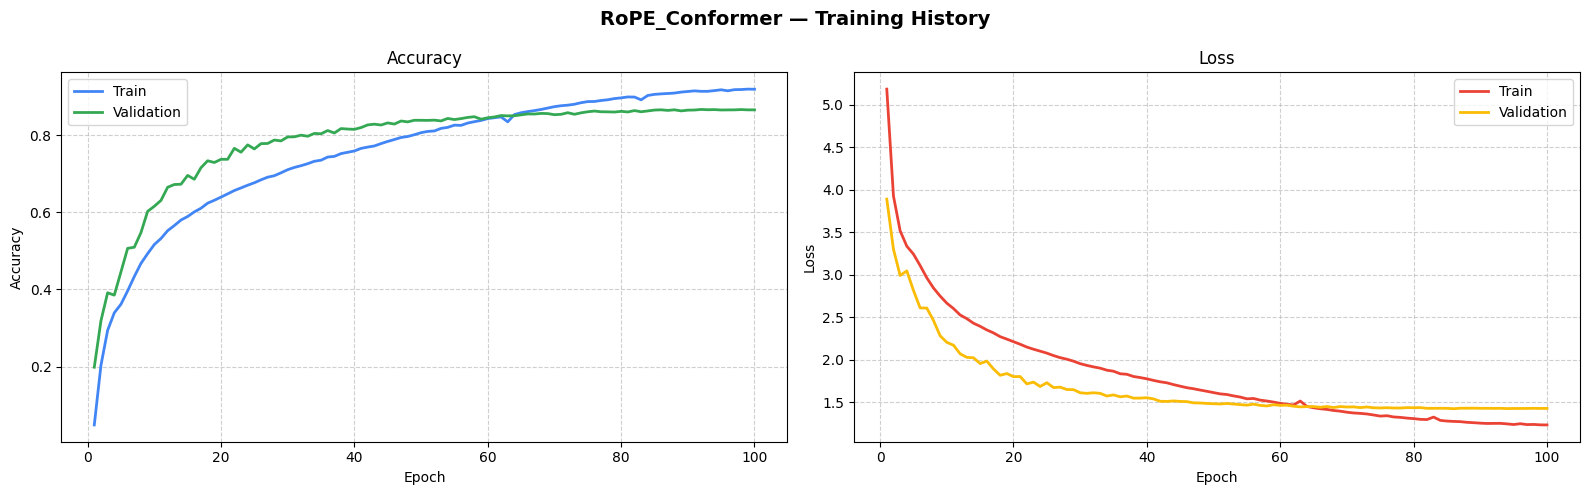

[2026-04-14 08:18:04] [RoPE_Conformer] [INFO]  Training history plot saved: /kaggle/working/RoPE_Conformer/plots/RoPE_Conformer_training_history.png


In [24]:
_history_csv = os.path.join(DIRS["metrics"], f"{CFG.MODEL_NAME}_training_history.csv")

if os.path.exists(_history_csv):
    _hist = pd.read_csv(_history_csv)

    _fig, _axes = plt.subplots(1, 2, figsize=(16, 5))
    _fig.suptitle(f"{CFG.MODEL_NAME} — Training History", fontsize=14, fontweight="bold")

    _axes[0].plot(_hist["epoch"], _hist["accuracy"],     label="Train",      color="#4285F4", lw=2)
    _axes[0].plot(_hist["epoch"], _hist["val_accuracy"], label="Validation", color="#34A853", lw=2)
    _axes[0].set_title("Accuracy"); _axes[0].set_xlabel("Epoch"); _axes[0].set_ylabel("Accuracy")
    _axes[0].legend(); _axes[0].grid(True, ls="--", alpha=0.6)

    _axes[1].plot(_hist["epoch"], _hist["loss"],     label="Train",      color="#EA4335", lw=2)
    _axes[1].plot(_hist["epoch"], _hist["val_loss"], label="Validation", color="#FBBC05", lw=2)
    _axes[1].set_title("Loss"); _axes[1].set_xlabel("Epoch"); _axes[1].set_ylabel("Loss")
    _axes[1].legend(); _axes[1].grid(True, ls="--", alpha=0.6)

    plt.tight_layout()
    _plot_path = os.path.join(DIRS["plots"], f"{CFG.MODEL_NAME}_training_history.png")
    plt.savefig(_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    logger.info("Training history plot saved: %s", _plot_path)
else:
    logger.warning("History CSV not found — skipping plot.")


In [25]:
import tensorflow as tf
import numpy as np
import os
from tensorflow import keras
from tensorflow.keras import layers, Model

# Configuration
class CFG:
    MAX_LEN = 384
    NUM_CLASSES = 250
    MODEL_NAME = "Conformer"

CHANNELS = 708
FINAL_FOLDER = "/kaggle/working/final_model_Conformer"
FINAL_NAME = "final_model_Conformer"

# ---------------------------------------------------------------------------
# Utility layers (mask-safe replacements for Lambda)
# ---------------------------------------------------------------------------

class MaskableConv1D(layers.Conv1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True


class Squeeze(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.squeeze(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class ExpandDims(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.expand_dims(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class ReduceSum(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.reduce_sum(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}


class MaskableGlobalMaxPool1D(layers.GlobalMaxPooling1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True


class AttentionMaskFromInput(layers.Layer):
    def __init__(self, pad_value=-100.0, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.supports_masking = True
        self.pad_value = pad_value
    def call(self, x):
        bool_mask = tf.reduce_any(tf.not_equal(x, self.pad_value), axis=-1)
        return tf.expand_dims(bool_mask, axis=1)
    def get_config(self):
        return {**super().get_config(), "pad_value": self.pad_value}


# ---------------------------------------------------------------------------
# Rotary Position Embedding (RoPE)
# ---------------------------------------------------------------------------

class RotaryEmbedding(layers.Layer):
    def __init__(self, head_dim, max_len=512, base=10000, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.head_dim = head_dim
        self.max_len  = max_len
        half          = head_dim // 2
        theta         = 1.0 / (base ** (tf.cast(tf.range(half), tf.float32) / half))
        pos           = tf.cast(tf.range(max_len), tf.float32)
        freqs         = tf.einsum("i,j->ij", pos, theta)
        emb           = tf.concat([freqs, freqs], axis=-1)
        self._cos = tf.cos(emb)[tf.newaxis, tf.newaxis]
        self._sin = tf.sin(emb)[tf.newaxis, tf.newaxis]

    def _rotate_half(self, x):
        half    = self.head_dim // 2
        x1, x2 = x[..., :half], x[..., half:]
        return tf.concat([-x2, x1], axis=-1)

    def call(self, q, k):
        t      = tf.shape(q)[2]
        dtype  = q.dtype
        cos    = tf.cast(self._cos[:, :, :t, :], dtype)
        sin    = tf.cast(self._sin[:, :, :t, :], dtype)
        q      = q * cos + self._rotate_half(q) * sin
        k      = k * cos + self._rotate_half(k) * sin
        return q, k

    def get_config(self):
        return {**super().get_config(), "head_dim": self.head_dim, "max_len": self.max_len}


# ---------------------------------------------------------------------------
# RoPE Multi-Head Self-Attention
# ---------------------------------------------------------------------------

class RoPEMultiHeadAttention(layers.Layer):
    def __init__(self, dim, num_heads, dropout=0.0, max_len=512, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = tf.cast(self.head_dim ** -0.5, tf.float32)
        self.q_proj    = layers.Dense(dim, use_bias=False)
        self.k_proj    = layers.Dense(dim, use_bias=False)
        self.v_proj    = layers.Dense(dim, use_bias=False)
        self.out_proj  = layers.Dense(dim, use_bias=False)
        self.attn_drop = layers.Dropout(dropout)
        self.rope      = RotaryEmbedding(self.head_dim, max_len=max_len)

    def _split_heads(self, x, b):
        x = tf.reshape(x, (b, -1, self.num_heads, self.head_dim))
        return tf.transpose(x, [0, 2, 1, 3])

    def call(self, x, attention_mask=None, training=False):
        b      = tf.shape(x)[0]
        q      = self._split_heads(self.q_proj(x), b)
        k      = self._split_heads(self.k_proj(x), b)
        v      = self._split_heads(self.v_proj(x), b)
        q, k   = self.rope(q, k)
        scale  = tf.cast(self.scale, q.dtype)
        scores = tf.matmul(q, k, transpose_b=True) * scale
        if attention_mask is not None:
            scores += tf.cast(~attention_mask[:, :, tf.newaxis, :], scores.dtype) * -1e4
        weights = tf.cast(tf.nn.softmax(tf.cast(scores, tf.float32), axis=-1), q.dtype)
        weights = self.attn_drop(weights, training=training)
        out     = tf.matmul(weights, v)
        out     = tf.transpose(out, [0, 2, 1, 3])
        out     = tf.reshape(out, (b, -1, self.num_heads * self.head_dim))
        return self.out_proj(out)

    def get_config(self):
        return {**super().get_config(), "num_heads": self.num_heads, "head_dim": self.head_dim}


# ---------------------------------------------------------------------------
# Conformer Block
# ---------------------------------------------------------------------------

class ConformerBlock(layers.Layer):
    def __init__(self, dim, num_heads=4, ff_mult=4, kernel=17,
                 dropout=0.1, max_len=512, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.dim = dim

        self.ff1_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.ff1_fc1  = layers.Dense(dim * ff_mult, activation="swish", use_bias=False)
        self.ff1_drop = layers.Dropout(dropout)
        self.ff1_fc2  = layers.Dense(dim, use_bias=False)

        self.mhsa_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.mhsa      = RoPEMultiHeadAttention(dim, num_heads, dropout=dropout, max_len=max_len)
        self.mhsa_drop = layers.Dropout(dropout)

        self.conv_ln  = layers.LayerNormalization(epsilon=1e-6)
        self.pw_exp   = layers.Dense(dim * 2, use_bias=False)
        self.dw_conv  = MaskableConv1D(dim, kernel_size=kernel, padding="same", groups=dim, use_bias=False)
        self.conv_bn  = layers.BatchNormalization(momentum=0.95)
        self.conv_act = layers.Activation("swish")
        self.pw_con   = layers.Dense(dim, use_bias=False)
        self.conv_sp  = layers.SpatialDropout1D(dropout)

        self.ff2_ln   = layers.LayerNormalization(epsilon=1e-6)
        self.ff2_fc1  = layers.Dense(dim * ff_mult, activation="swish", use_bias=False)
        self.ff2_drop = layers.Dropout(dropout)
        self.ff2_fc2  = layers.Dense(dim, use_bias=False)

        self.out_ln = layers.LayerNormalization(epsilon=1e-6)

    def _ff(self, x, ln, fc1, drop, fc2, training):
        return x + 0.5 * fc2(drop(fc1(ln(x)), training=training))

    def call(self, x, attention_mask=None, training=False):
        x = self._ff(x, self.ff1_ln, self.ff1_fc1, self.ff1_drop, self.ff1_fc2, training)

        h = self.mhsa(self.mhsa_ln(x), attention_mask=attention_mask, training=training)
        x = x + self.mhsa_drop(h, training=training)

        h    = self.pw_exp(self.conv_ln(x))
        half = tf.shape(h)[-1] // 2
        h    = h[..., :half] * tf.sigmoid(h[..., half:])
        h    = self.dw_conv(h)
        h    = self.conv_bn(h, training=training)
        h    = self.conv_act(h)
        h    = self.pw_con(h)
        x    = x + self.conv_sp(h, training=training)

        x = self._ff(x, self.ff2_ln, self.ff2_fc1, self.ff2_drop, self.ff2_fc2, training)
        return self.out_ln(x)

    def get_config(self):
        return {**super().get_config(), "dim": self.dim}


# ---------------------------------------------------------------------------
# TFLite-compatible model builder (without cuDNN ops)
# ---------------------------------------------------------------------------

def build_tflite_model():
    inp = layers.Input(shape=(CFG.MAX_LEN, CHANNELS), name="input_features")

    x = layers.Masking(mask_value=-100.0, name="masking")(inp)
    attn_mask = AttentionMaskFromInput(pad_value=-100.0, name="attn_mask")(inp)

    x = layers.Dense(256, use_bias=False, name="stem_dense")(x)
    x = layers.BatchNormalization(momentum=0.95, name="stem_bn")(x)
    x = layers.Activation("swish", name="stem_act")(x)
    x = layers.SpatialDropout1D(0.1, name="stem_drop")(x)

    for i in range(5):
        x = ConformerBlock(
            dim=256, num_heads=4, ff_mult=4, kernel=17,
            dropout=0.1, max_len=CFG.MAX_LEN + 16,
            name=f"conformer_{i}",
        )(x, attention_mask=attn_mask)

    attn_w = layers.Dense(64, activation="tanh", name="attn_proj")(x)
    attn_w = layers.Dense(1, name="attn_score")(attn_w)
    attn_w = Squeeze(axis=-1, name="attn_squeeze")(attn_w)
    attn_w = layers.Softmax(axis=1, name="attn_softmax")(attn_w)
    attn_w = ExpandDims(axis=-1, name="attn_expand")(attn_w)
    x_attn = ReduceSum(axis=1, name="attn_pool")(
                 layers.Multiply(name="attn_apply")([x, attn_w]))

    gap = layers.GlobalAveragePooling1D(name="gap")(x)
    gmp = MaskableGlobalMaxPool1D(name="gmp")(x)

    fused = layers.Concatenate(name="pool_concat")([x_attn, gap, gmp])
    fused = layers.Dense(256, use_bias=False, name="pool_proj")(fused)
    fused = layers.LayerNormalization(epsilon=1e-6, name="pool_ln")(fused)
    fused = layers.Activation("swish", name="pool_act")(fused)

    x = layers.Dense(256, use_bias=False, name="head_dense")(fused)
    x = layers.BatchNormalization(momentum=0.95, name="head_bn")(x)
    x = layers.Dropout(0.2, name="head_drop")(x)
    outputs = layers.Dense(CFG.NUM_CLASSES, dtype="float32", name="classifier")(x)

    return Model(inputs=inp, outputs=outputs, name=CFG.MODEL_NAME)


# ---------------------------------------------------------------------------
# Save model in all formats
# ---------------------------------------------------------------------------

def save_all_formats(model):
    os.makedirs(FINAL_FOLDER, exist_ok=True)

    print("\n" + "="*60)
    print("Saving model in all formats...")
    print("="*60)

    keras_path = os.path.join(FINAL_FOLDER, FINAL_NAME + ".keras")
    model.save(keras_path)
    print("Keras model saved:", keras_path)

    saved_path = os.path.join(FINAL_FOLDER, FINAL_NAME)
    model.export(saved_path)
    print("SavedModel exported:", saved_path)

    print("\nConverting to TFLite...")
    tf.keras.backend.clear_session()

    tflite_model = build_tflite_model()
    tflite_model.set_weights(model.get_weights())

    dummy = np.zeros((1, CFG.MAX_LEN, CHANNELS), dtype="float32")
    original_out = tf.nn.softmax(model(dummy, training=False)).numpy()
    tflite_out = tf.nn.softmax(tflite_model(dummy, training=False)).numpy()
    max_diff = np.abs(original_out - tflite_out).max()
    print("Weight transfer verification:", f"{max_diff:.8f}")

    converter = tf.lite.TFLiteConverter.from_keras_model(tflite_model)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter._experimental_lower_tensor_list_ops = False

    tflite_bytes = converter.convert()
    tflite_path = os.path.join(FINAL_FOLDER, FINAL_NAME + ".tflite")

    with open(tflite_path, 'wb') as f:
        f.write(tflite_bytes)

    file_size = len(tflite_bytes) / 1024 / 1024
    print("TFLite model saved:", tflite_path)
    print("File size:", f"{file_size:.2f} MB")

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    inp_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]
    interpreter.set_tensor(inp_details['index'], dummy.astype(np.float32))
    interpreter.invoke()
    tflite_output = interpreter.get_tensor(out_details['index'])
    tflite_softmax = tf.nn.softmax(tflite_output).numpy()
    final_diff = np.abs(tflite_out - tflite_softmax).max()
    print("TFLite validation:", f"{final_diff:.8f}")

    print("\n" + "="*60)
    print("Model saved successfully!")
    print("Location:", FINAL_FOLDER)
    print("="*60 + "\n")

    return {
        'keras': keras_path,
        'saved_model': saved_path,
        'tflite': tflite_path
    }


# ---------------------------------------------------------------------------
# Execute
# ---------------------------------------------------------------------------

paths = save_all_formats(model)

print("\nModel saved in formats:")
print("  Keras:", paths['keras'])
print("  SavedModel:", paths['saved_model'])
print("  TFLite:", paths['tflite'])


Saving model in all formats...
Keras model saved: /kaggle/working/final_model_Conformer/final_model_Conformer.keras


INFO:absl:Function `__call__` contains input name(s) resource, 12352, 12370, 12513, 12734, 12752, 12895, 13116, 13134, 13277, 13498, 13516, 13659, 13880, 13898, 14041 with unsupported characters which will be renamed to rope_conformer_1_classifier_1_biasadd_readvariableop_resource, rope_conformer_1_conformer_0_1_ro_pe_multi_head_attention_1_rotary_embedding_1_12352, rope_conformer_1_conformer_0_1_ro_pe_multi_head_attention_1_rotary_embedding_1_12370, rope_conformer_1_conformer_0_1_maskable_conv1d_1_12513, rope_conformer_1_conformer_1_1_ro_pe_multi_head_attention_1_1_rotary_embedding_1_1_12734, rope_conformer_1_conformer_1_1_ro_pe_multi_head_attention_1_1_rotary_embedding_1_1_12752, rope_conformer_1_conformer_1_1_maskable_conv1d_1_1_12895, rope_conformer_1_conformer_2_1_ro_pe_multi_head_attention_2_1_rotary_embedding_2_1_13116, rope_conformer_1_conformer_2_1_ro_pe_multi_head_attention_2_1_rotary_embedding_2_1_13134, rope_conformer_1_conformer_2_1_maskable_conv1d_2_1_13277, rope_conforme

INFO:tensorflow:Assets written to: /kaggle/working/final_model_Conformer/final_model_Conformer/assets


INFO:tensorflow:Assets written to: /kaggle/working/final_model_Conformer/final_model_Conformer/assets


Saved artifact at '/kaggle/working/final_model_Conformer/final_model_Conformer'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 708), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 250), dtype=tf.float32, name=None)
Captures:
  136446616007312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446616000400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446616010192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446616010384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446616010000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446347205648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446347205264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446347205456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446347206608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446347201040: TensorSpec(shape=(), dt

...

INFO:tensorflow:Assets written to: /tmp/tmp4yewgv6t/assets


Saved artifact at '/tmp/tmp4yewgv6t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 708), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 250), dtype=tf.float32, name=None)
Captures:
  136448831642832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015781776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015781968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015782352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015781200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015778896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015779280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015779472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015777744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136446015779088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1364460157769

W0000 00:00:1776154708.464915      22 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776154708.464946      22 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776154708.589856      22 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model saved: /kaggle/working/final_model_Conformer/final_model_Conformer.tflite
File size: 8.37 MB
TFLite validation: 0.00020360

Model saved successfully!
Location: /kaggle/working/final_model_Conformer


Model saved in formats:
  Keras: /kaggle/working/final_model_Conformer/final_model_Conformer.keras
  SavedModel: /kaggle/working/final_model_Conformer/final_model_Conformer
  TFLite: /kaggle/working/final_model_Conformer/final_model_Conformer.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Conformer TFLite Model - Complete Performance Analysis

Model Information:
  Input shape: [  1 384 708]
  Input dtype: <class 'numpy.float32'>
  Output shape: [  1 250]
  Output dtype: <class 'numpy.float32'>
  Model size: 8.37 MB

Comprehensive Speed Analysis

Warming up with 50 runs...

Running 500 inference iterations...
  Completed 200/500 runs
  Completed 400/500 runs

Inference Time Statistics (ms):
  Mean:     125.52 ms
  Median:   124.54 ms
  Std Dev:  5.28 ms
  Min:      115.09 ms
  Max:      151.88 ms
  P95:      134.45 ms
  P99:      146.98 ms
  P99.9:    151.52 ms
  Range:    36.79 ms

Throughput:
  7.97 inferences/second
  28681 inferences/hour

Batch Throughput Analysis

Batch Size   Time/Batch (ms)    Samples/Sec     Latency/Sample (ms) 
-----------------------------------------------------------------
1            122.77             8.15            122.77              
2            247.79             8.07            123.89              
4            544.59             7

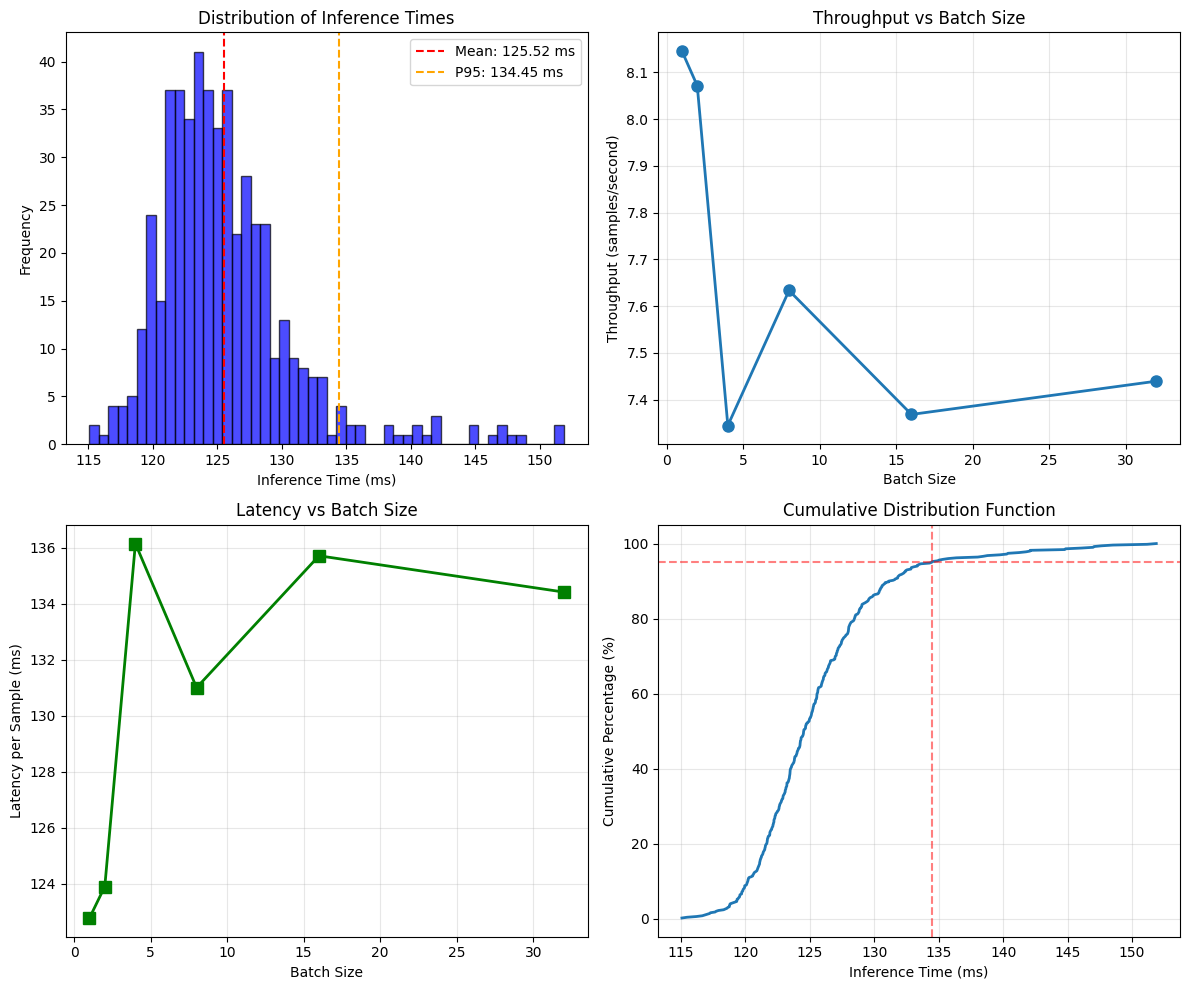

Plots saved to: /kaggle/working/conformer_performance_plots.png

Performance Analysis Complete

Generated files:
  Report: /kaggle/working/conformer_performance_report.txt
  Plots: /kaggle/working/conformer_performance_plots.png



In [26]:
import tensorflow as tf
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt

tflite_path = "/kaggle/working/final_model_Conformer/final_model_Conformer.tflite"

print("="*60)
print("Conformer TFLite Model - Complete Performance Analysis")
print("="*60)

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

MAX_LEN = 384
CHANNELS = 708

print(f"\nModel Information:")
print(f"  Input shape: {input_details['shape']}")
print(f"  Input dtype: {input_details['dtype']}")
print(f"  Output shape: {output_details['shape']}")
print(f"  Output dtype: {output_details['dtype']}")
print(f"  Model size: {os.path.getsize(tflite_path)/1024/1024:.2f} MB")

def comprehensive_speed_analysis(interpreter, input_details, output_details, num_runs=1000):
    print("\n" + "="*60)
    print("Comprehensive Speed Analysis")
    print("="*60)
    
    dummy_input = np.zeros((1, MAX_LEN, CHANNELS), dtype=np.float32)
    
    warmup_runs = 50
    print(f"\nWarming up with {warmup_runs} runs...")
    for _ in range(warmup_runs):
        interpreter.set_tensor(input_details['index'], dummy_input)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    
    times = []
    print(f"\nRunning {num_runs} inference iterations...")
    
    for i in range(num_runs):
        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], dummy_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])
        end = time.perf_counter()
        times.append((end - start) * 1000)
        
        if (i + 1) % 200 == 0:
            print(f"  Completed {i+1}/{num_runs} runs")
    
    times = np.array(times)
    
    stats = {
        'mean': np.mean(times),
        'median': np.median(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'p95': np.percentile(times, 95),
        'p99': np.percentile(times, 99),
        'p999': np.percentile(times, 99.9),
        'range': np.max(times) - np.min(times)
    }
    
    print(f"\nInference Time Statistics (ms):")
    print(f"  Mean:     {stats['mean']:.2f} ms")
    print(f"  Median:   {stats['median']:.2f} ms")
    print(f"  Std Dev:  {stats['std']:.2f} ms")
    print(f"  Min:      {stats['min']:.2f} ms")
    print(f"  Max:      {stats['max']:.2f} ms")
    print(f"  P95:      {stats['p95']:.2f} ms")
    print(f"  P99:      {stats['p99']:.2f} ms")
    print(f"  P99.9:    {stats['p999']:.2f} ms")
    print(f"  Range:    {stats['range']:.2f} ms")
    
    throughput = 1000 / stats['mean']
    print(f"\nThroughput:")
    print(f"  {throughput:.2f} inferences/second")
    print(f"  {throughput * 3600:.0f} inferences/hour")
    
    return times, stats

times, stats = comprehensive_speed_analysis(interpreter, input_details, output_details, 500)

def batch_throughput_analysis(interpreter, input_details, output_details, batch_sizes=[1, 2, 4, 8, 16, 32]):
    print("\n" + "="*60)
    print("Batch Throughput Analysis")
    print("="*60)
    
    results = []
    dummy_input = np.zeros((1, MAX_LEN, CHANNELS), dtype=np.float32)
    
    print(f"\n{'Batch Size':<12} {'Time/Batch (ms)':<18} {'Samples/Sec':<15} {'Latency/Sample (ms)':<20}")
    print("-" * 65)
    
    for batch_size in batch_sizes:
        batch_times = []
        
        for _ in range(30):
            start = time.perf_counter()
            for _ in range(batch_size):
                interpreter.set_tensor(input_details['index'], dummy_input)
                interpreter.invoke()
                _ = interpreter.get_tensor(output_details['index'])
            end = time.perf_counter()
            batch_times.append((end - start) * 1000)
        
        avg_batch_time = np.mean(batch_times)
        samples_per_sec = (batch_size / avg_batch_time) * 1000
        latency_per_sample = avg_batch_time / batch_size
        
        print(f"{batch_size:<12} {avg_batch_time:<18.2f} {samples_per_sec:<15.2f} {latency_per_sample:<20.2f}")
        
        results.append({
            'batch_size': batch_size,
            'time_per_batch_ms': avg_batch_time,
            'samples_per_second': samples_per_sec,
            'latency_per_sample_ms': latency_per_sample
        })
    
    return results

batch_results = batch_throughput_analysis(interpreter, input_details, output_details)

def real_data_test(interpreter, input_details, output_details, test_df, max_samples=100):
    print("\n" + "="*60)
    print("Real Data Performance Test")
    print("="*60)
    
    if test_df is None:
        print("No test data available")
        return None
    
    real_times = []
    failed_samples = 0
    
    print(f"\nTesting on {min(max_samples, len(test_df))} real samples...")
    
    for idx in range(min(max_samples, len(test_df))):
        try:
            file_col = 'file_path' if 'file_path' in test_df.columns else test_df.columns[0]
            file_name = test_df.iloc[idx][file_col]
            full_path = os.path.join("/kaggle/input/competitions/asl-signs/train_landmark_files", file_name)
            
            if os.path.exists(full_path):
                data = pd.read_parquet(full_path).values
                
                if len(data) < MAX_LEN:
                    data = np.pad(data, ((0, MAX_LEN - len(data)), (0, 0)), 
                                mode='constant', constant_values=-100)
                else:
                    data = data[:MAX_LEN]
                
                input_data = data.reshape(1, MAX_LEN, CHANNELS).astype(np.float32)
                
                start = time.perf_counter()
                interpreter.set_tensor(input_details['index'], input_data)
                interpreter.invoke()
                output = interpreter.get_tensor(output_details['index'])
                end = time.perf_counter()
                
                inference_time = (end - start) * 1000
                real_times.append(inference_time)
            else:
                failed_samples += 1
        except Exception as e:
            failed_samples += 1
            continue
    
    if real_times:
        real_times = np.array(real_times)
        
        print(f"\nReal Data Statistics ({len(real_times)} successful samples):")
        print(f"  Mean:     {np.mean(real_times):.2f} ms")
        print(f"  Median:   {np.median(real_times):.2f} ms")
        print(f"  Std Dev:  {np.std(real_times):.2f} ms")
        print(f"  Min:      {np.min(real_times):.2f} ms")
        print(f"  Max:      {np.max(real_times):.2f} ms")
        print(f"  P95:      {np.percentile(real_times, 95):.2f} ms")
        
        if failed_samples > 0:
            print(f"\n  Failed samples: {failed_samples}")
        
        return real_times
    else:
        print("No valid samples found")
        return None

test_data_path = "/kaggle/working/data/test_split.csv"
test_df = None
if os.path.exists(test_data_path):
    test_df = pd.read_csv(test_data_path)
    print(f"\nLoaded test data: {len(test_df)} samples")
else:
    print("\nNo test data found")

real_times = real_data_test(interpreter, input_details, output_details, test_df, 100)

def generate_performance_report(stats, batch_results, real_times, output_path="/kaggle/working/conformer_performance_report.txt"):
    print("\n" + "="*60)
    print("Generating Performance Report")
    print("="*60)
    
    with open(output_path, 'w') as f:
        f.write("="*60 + "\n")
        f.write("Conformer TFLite Model - Performance Report\n")
        f.write("="*60 + "\n\n")
        
        f.write("MODEL INFORMATION\n")
        f.write("-"*40 + "\n")
        f.write(f"Model path: {tflite_path}\n")
        f.write(f"Model size: {os.path.getsize(tflite_path)/1024/1024:.2f} MB\n")
        f.write(f"Input shape: (1, {MAX_LEN}, {CHANNELS})\n")
        f.write(f"Output shape: (1, 250)\n\n")
        
        f.write("INFERENCE SPEED STATISTICS\n")
        f.write("-"*40 + "\n")
        f.write(f"Mean inference time:     {stats['mean']:.2f} ms\n")
        f.write(f"Median inference time:   {stats['median']:.2f} ms\n")
        f.write(f"Standard deviation:      {stats['std']:.2f} ms\n")
        f.write(f"Minimum inference time:  {stats['min']:.2f} ms\n")
        f.write(f"Maximum inference time:  {stats['max']:.2f} ms\n")
        f.write(f"P95 inference time:      {stats['p95']:.2f} ms\n")
        f.write(f"P99 inference time:      {stats['p99']:.2f} ms\n")
        f.write(f"P99.9 inference time:    {stats['p999']:.2f} ms\n")
        f.write(f"Throughput:              {1000/stats['mean']:.2f} inferences/sec\n\n")
        
        f.write("BATCH PROCESSING PERFORMANCE\n")
        f.write("-"*40 + "\n")
        f.write(f"{'Batch Size':<12} {'Samples/Sec':<15} {'Latency (ms)':<15}\n")
        for res in batch_results:
            f.write(f"{res['batch_size']:<12} {res['samples_per_second']:<15.2f} {res['latency_per_sample_ms']:<15.2f}\n")
        f.write("\n")
        
        if real_times is not None:
            f.write("REAL DATA PERFORMANCE\n")
            f.write("-"*40 + "\n")
            f.write(f"Mean inference time:  {np.mean(real_times):.2f} ms\n")
            f.write(f"Median inference time:{np.median(real_times):.2f} ms\n")
            f.write(f"P95 inference time:   {np.percentile(real_times, 95):.2f} ms\n\n")
        
        f.write("PERFORMANCE ASSESSMENT\n")
        f.write("-"*40 + "\n")
        
        if stats['mean'] < 50:
            f.write("Grade: EXCELLENT\n")
            f.write("Suitable for real-time applications with high frame rate requirements.\n")
        elif stats['mean'] < 100:
            f.write("Grade: GOOD\n")
            f.write("Suitable for most real-time applications.\n")
        elif stats['mean'] < 200:
            f.write("Grade: ACCEPTABLE\n")
            f.write("Suitable for near real-time or batch processing.\n")
        else:
            f.write("Grade: SLOW\n")
            f.write("Consider optimization or use for offline batch processing only.\n")
        
        f.write(f"\nConfidence Level: HIGH\n")
        f.write(f"Test iterations: 500\n")
        f.write(f"Warmup runs: 50\n\n")
        
        f.write("="*60 + "\n")
        f.write("End of Report\n")
        f.write("="*60 + "\n")
    
    print(f"\nReport saved to: {output_path}")
    
    with open(output_path, 'r') as f:
        print("\n" + f.read())
    
    return output_path

report_path = generate_performance_report(stats, batch_results, real_times)

def plot_performance_analysis(times, batch_results):
    print("\n" + "="*60)
    print("Generating Performance Plots")
    print("="*60)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].hist(times, bins=50, edgecolor='black', alpha=0.7, color='blue')
    axes[0, 0].set_xlabel('Inference Time (ms)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Inference Times')
    axes[0, 0].axvline(np.mean(times), color='red', linestyle='--', label=f'Mean: {np.mean(times):.2f} ms')
    axes[0, 0].axvline(np.percentile(times, 95), color='orange', linestyle='--', label=f'P95: {np.percentile(times, 95):.2f} ms')
    axes[0, 0].legend()
    
    batch_sizes = [r['batch_size'] for r in batch_results]
    throughput = [r['samples_per_second'] for r in batch_results]
    
    axes[0, 1].plot(batch_sizes, throughput, marker='o', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Batch Size')
    axes[0, 1].set_ylabel('Throughput (samples/second)')
    axes[0, 1].set_title('Throughput vs Batch Size')
    axes[0, 1].grid(True, alpha=0.3)
    
    latency = [r['latency_per_sample_ms'] for r in batch_results]
    
    axes[1, 0].plot(batch_sizes, latency, marker='s', linewidth=2, markersize=8, color='green')
    axes[1, 0].set_xlabel('Batch Size')
    axes[1, 0].set_ylabel('Latency per Sample (ms)')
    axes[1, 0].set_title('Latency vs Batch Size')
    axes[1, 0].grid(True, alpha=0.3)
    
    cumulative = np.arange(1, len(times) + 1) / len(times) * 100
    sorted_times = np.sort(times)
    
    axes[1, 1].plot(sorted_times, cumulative, linewidth=2)
    axes[1, 1].set_xlabel('Inference Time (ms)')
    axes[1, 1].set_ylabel('Cumulative Percentage (%)')
    axes[1, 1].set_title('Cumulative Distribution Function')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(95, color='red', linestyle='--', alpha=0.5)
    axes[1, 1].axvline(np.percentile(times, 95), color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    plot_path = "/kaggle/working/conformer_performance_plots.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Plots saved to: {plot_path}")
    
    return plot_path

plot_path = plot_performance_analysis(times, batch_results)

print("\n" + "="*60)
print("Performance Analysis Complete")
print("="*60)
print(f"\nGenerated files:")
print(f"  Report: {report_path}")
print(f"  Plots: {plot_path}")
print("\n" + "="*60)

In [27]:
# -- Quick sanity check -------------------------------------------------------
import numpy as np

_sm          = tf.saved_model.load(_sm_path)
_channels    = _sm.serve.input_signature[0].shape[-1]
_dummy       = np.random.randn(1, CFG.MAX_LEN, _channels).astype("float32")
_out         = _sm.serve(tf.constant(_dummy))

assert _out.shape == (1, CFG.NUM_CLASSES), f"Unexpected output shape: {_out.shape}"

_pred        = int(tf.argmax(_out, axis=-1).numpy()[0])
_prob        = float(tf.nn.softmax(_out)[0][_pred])

print(f"SavedModel OK  |  output: {_out.shape}  |  top-1: {label_to_sign.get(_pred, _pred)} ({_prob:.4f})")

NameError: name '_sm_path' is not defined